In [16]:
import csv
import pandas as pd

In [17]:
params = {
    'fileLocation': 'database\\winemag-data-130k-v2_clean.csv',
}

In [18]:
df = csv.reader(open(params['fileLocation'], 'r', encoding='utf-8'))
columns = next(df)
columns[0] = 'id'  # Az első oszlop neve 'id' legyen
df = pd.DataFrame(df, columns=columns)

print(df.shape)
display(df.head())

(129971, 7)


,id,country,description,points,province,region_1,region_2
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",87,Sicily & Sardinia,Etna,
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",87,Douro,,
2,2,US,"Tart and snappy, the flavors of lime flesh and...",87,Oregon,Willamette Valley,Willamette Valley
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",87,Michigan,Lake Michigan Shore,
4,4,US,"Much like the regular bottling from 2012, this...",87,Oregon,Willamette Valley,Willamette Valley


In [19]:
df_description = df[['id', 'description', 'points']]
# df_description.head(5)

df_description['group'] = pd.qcut(df_description['points'].astype(int),
                                 q=4,
                                 labels=['poor', 'below_avg', 'above_avg', 'excellent'])

# display(df_description['group'].value_counts())
display(df_description.head(5))

C:\Users\2314l\AppData\Local\Temp\ipykernel_8440\1196602354.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_description['group'] = pd.qcut(df_description['points'].astype(int),


,id,description,points,group
0,0,"Aromas include tropical fruit, broom, brimston...",87,below_avg
1,1,"This is ripe and fruity, a wine that is smooth...",87,below_avg
2,2,"Tart and snappy, the flavors of lime flesh and...",87,below_avg
3,3,"Pineapple rind, lemon pith and orange blossom ...",87,below_avg
4,4,"Much like the regular bottling from 2012, this...",87,below_avg


## Szöveg előkészítés és TF-IDF elemzés

A cél: A description alapján kategorizálni a borokat (poor, below_avg, above_avg, excellent)

Használt módszer:
- **TF-IDF (Term Frequency-Inverse Document Frequency)**: megtalálja az egyes kategóriákra jellemző szavakat
- **Szöveg tisztítás**: stopwords eltávolítása, kisbetűsítés
- **Machine Learning**: klasszifikáció a szöveges jellemzők alapján

In [20]:
# Szükséges könyvtárak importálása
import re
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# NLTK stopwords letöltése (első futtatáskor szükséges)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

from nltk.corpus import stopwords

print("Könyvtárak betöltve!")

Könyvtárak betöltve!


In [21]:
# Szöveg tisztítási függvény
def clean_text(text):
    """
    Szöveg tisztítása:
    - Kisbetűsítés
    - Speciális karakterek eltávolítása
    - Többszörös szóközök eltávolítása
    """
    if pd.isna(text):
        return ""
    
    # Kisbetűsítés
    text = text.lower()
    
    # Csak betűk és szóközök megtartása
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Többszörös szóközök eltávolítása
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Tisztított szövegek létrehozása
df_description['description_clean'] = df_description['description'].apply(clean_text)

print("Példa tisztított szövegre:")
print(f"Eredeti: {df_description['description'].iloc[0][:100]}...")
print(f"Tisztított: {df_description['description_clean'].iloc[0][:100]}...")

Példa tisztított szövegre:
Eredeti: Aromas include tropical fruit, broom, brimstone and dried herb. The palate isn't overly expressive, ...
Tisztított: aromas include tropical fruit broom brimstone and dried herb the palate isn t overly expressive offe...


C:\Users\2314l\AppData\Local\Temp\ipykernel_8440\2271840318.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_description['description_clean'] = df_description['description'].apply(clean_text)


In [22]:
# Kategóriák eloszlásának ellenőrzése
print("Kategóriák eloszlása:")
print(df_description['group'].value_counts().sort_index())
print(f"\nÖsszesen: {len(df_description)} minta")

Kategóriák eloszlása:
group
poor         34560
below_avg    34140
above_avg    38995
excellent    22276
Name: count, dtype: int64

Összesen: 129971 minta


### TF-IDF elemzés

A TF-IDF (Term Frequency-Inverse Document Frequency) megmutatja, mely szavak jellemzőek az egyes kategóriákra:
- **TF (Term Frequency)**: egy szó gyakorisága egy dokumentumban
- **IDF (Inverse Document Frequency)**: egy szó ritkasága az összes dokumentumban

Így a kategóriára jellemző, de általában ritka szavak kapnak magas pontszámot.

In [23]:
# TF-IDF vectorizer létrehozása
stop_words_en = stopwords.words('english')

# TF-IDF paraméterek:
# - max_features: legfontosabb 5000 szó
# - min_df: legalább 5 dokumentumban szerepeljen
# - max_df: maximum a dokumentumok 80%-ában szerepelhet (túl gyakori szavak kiszűrése)
# - ngram_range: 1-2 szavas kifejezések (pl. "cherry flavors")

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    stop_words=stop_words_en,
    ngram_range=(1, 2)
)

# TF-IDF mátrix létrehozása
X = tfidf.fit_transform(df_description['description_clean'])
y = df_description['group']

print(f"TF-IDF mátrix mérete: {X.shape}")
print(f"Szavak száma a vocabulary-ban: {len(tfidf.vocabulary_)}")

TF-IDF mátrix mérete: (129971, 5000)
Szavak száma a vocabulary-ban: 5000


In [24]:
# Kategóriánként legjellemzőbb szavak megtalálása
def get_top_tfidf_words_per_category(category, top_n=15):
    """
    Megtalálja a kategóriára legjellemzőbb szavakat
    """
    # Adott kategóriához tartozó indexek
    category_indices = df_description[df_description['group'] == category].index
    
    # TF-IDF értékek átlaga a kategórián belül
    category_tfidf = X[category_indices].mean(axis=0).A1
    
    # Top szavak indexei
    top_indices = category_tfidf.argsort()[-top_n:][::-1]
    
    # Szavak és értékek
    feature_names = tfidf.get_feature_names_out()
    top_words = [(feature_names[i], category_tfidf[i]) for i in top_indices]
    
    return top_words

# Minden kategóriára
categories = ['poor', 'below_avg', 'above_avg', 'excellent']

print("=" * 80)
for category in categories:
    top_words = get_top_tfidf_words_per_category(category, top_n=15)
    print(f"\n{category.upper()} kategória legjellemzőbb szavai:")
    print("-" * 80)
    for word, score in top_words:
        print(f"  {word:30s} {score:.4f}")
print("=" * 80)


POOR kategória legjellemzőbb szavai:
--------------------------------------------------------------------------------
  flavors                        0.0383
  wine                           0.0364
  fruit                          0.0270
  aromas                         0.0254
  finish                         0.0251
  acidity                        0.0227
  palate                         0.0208
  soft                           0.0199
  sweet                          0.0196
  red                            0.0189
  light                          0.0187
  cherry                         0.0183
  drink                          0.0180
  dry                            0.0177
  simple                         0.0164

BELOW_AVG kategória legjellemzőbb szavai:
--------------------------------------------------------------------------------
  wine                           0.0364
  flavors                        0.0311
  fruit                          0.0284
  aromas                         0.02

### Machine Learning modell építése

Most felépítünk egy klasszifikációs modellt, ami a TF-IDF jellemzők alapján megjósolja a bor kategóriáját.

In [25]:
# Adatok felosztása train és test halmazra (80-20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train halmaz: {X_train.shape[0]} minta")
print(f"Test halmaz: {X_test.shape[0]} minta")
print(f"\nTrain halmaz eloszlása:")
print(y_train.value_counts().sort_index())

Train halmaz: 103976 minta
Test halmaz: 25995 minta

Train halmaz eloszlása:
group
poor         27648
below_avg    27312
above_avg    31196
excellent    17820
Name: count, dtype: int64


In [26]:
# 1. Logistic Regression modell
print("=" * 80)
print("LOGISTIC REGRESSION")
print("=" * 80)

lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
lr_model.fit(X_train, y_train)

# Predikció
y_pred_lr = lr_model.predict(X_test)

# Értékelés
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Pontosság
accuracy_lr = lr_model.score(X_test, y_test)
print(f"\nPontosság: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")

LOGISTIC REGRESSION


LOGISTIC REGRESSION


c:\Egyetem\Adattudomány\Projekt\Adattudomany-Projektmunka\venv_betegut\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LOGISTIC REGRESSION


c:\Egyetem\Adattudomány\Projekt\Adattudomany-Projektmunka\venv_betegut\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Classification Report:
              precision    recall  f1-score   support

   above_avg       0.53      0.61      0.56      7799
   below_avg       0.48      0.43      0.45      6828
   excellent       0.66      0.56      0.60      4456
        poor       0.70      0.72      0.71      6912

    accuracy                           0.58     25995
   macro avg       0.59      0.58      0.58     25995
weighted avg       0.58      0.58      0.58     25995


Pontosság: 0.5821 (58.21%)


In [27]:
# 2. Multinomial Naive Bayes modell
print("\n" + "=" * 80)
print("MULTINOMIAL NAIVE BAYES")
print("=" * 80)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Predikció
y_pred_nb = nb_model.predict(X_test)

# Értékelés
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

# Pontosság
accuracy_nb = nb_model.score(X_test, y_test)
print(f"\nPontosság: {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)")


MULTINOMIAL NAIVE BAYES

Classification Report:
              precision    recall  f1-score   support

   above_avg       0.47      0.64      0.54      7799
   below_avg       0.46      0.33      0.38      6828
   excellent       0.62      0.40      0.49      4456
        poor       0.63      0.69      0.66      6912

    accuracy                           0.53     25995
   macro avg       0.54      0.51      0.52     25995
weighted avg       0.54      0.53      0.52     25995


Pontosság: 0.5303 (53.03%)

Classification Report:
              precision    recall  f1-score   support

   above_avg       0.47      0.64      0.54      7799
   below_avg       0.46      0.33      0.38      6828
   excellent       0.62      0.40      0.49      4456
        poor       0.63      0.69      0.66      6912

    accuracy                           0.53     25995
   macro avg       0.54      0.51      0.52     25995
weighted avg       0.54      0.53      0.52     25995


Pontosság: 0.5303 (53.03%)


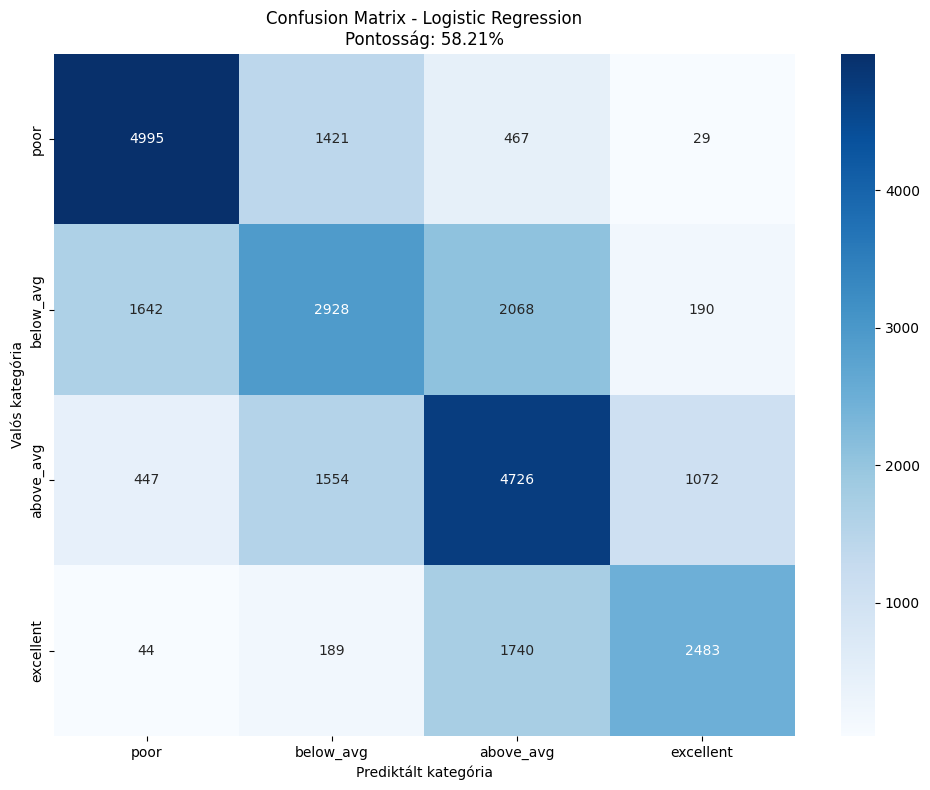


Legjobb modell: Logistic Regression
Logistic Regression pontosság: 58.21%
Naive Bayes pontosság: 53.03%


In [28]:
# Confusion Matrix vizualizáció a legjobb modellhez
best_model_name = "Logistic Regression" if accuracy_lr >= accuracy_nb else "Naive Bayes"
best_predictions = y_pred_lr if accuracy_lr >= accuracy_nb else y_pred_nb

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, best_predictions, labels=categories)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=categories, yticklabels=categories)
plt.title(f'Confusion Matrix - {best_model_name}\nPontosság: {max(accuracy_lr, accuracy_nb):.2%}')
plt.ylabel('Valós kategória')
plt.xlabel('Prediktált kategória')
plt.tight_layout()
plt.show()

print(f"\nLegjobb modell: {best_model_name}")
print(f"Logistic Regression pontosság: {accuracy_lr:.2%}")
print(f"Naive Bayes pontosság: {accuracy_nb:.2%}")

### Tesztelés új borleírásokkal

Most teszteljük a modellt néhány új borleírással, hogy lássuk, hogyan működik a gyakorlatban.

In [29]:
# Példa borleírások különböző minőségekre
test_descriptions = [
    "Simple and watery wine with little character.",
    "Pleasant wine with decent fruit flavors and balanced acidity.",
    "Complex wine with rich layers of dark fruit, well-integrated oak and silky tannins.",
    "Exceptional wine with intense concentration, profound complexity and remarkable elegance. A masterpiece."
]

# Legjobb modell kiválasztása
best_model = lr_model if accuracy_lr >= accuracy_nb else nb_model

print("=" * 80)
print("TESZTELÉS ÚJ BORLEÍRÁSOKKAL")
print("=" * 80)

for i, desc in enumerate(test_descriptions, 1):
    # Szöveg tisztítás
    clean_desc = clean_text(desc)
    
    # TF-IDF transzformáció
    desc_tfidf = tfidf.transform([clean_desc])
    
    # Predikció
    prediction = best_model.predict(desc_tfidf)[0]
    probabilities = best_model.predict_proba(desc_tfidf)[0]
    
    print(f"\n{i}. Leírás:")
    print(f"   '{desc}'")
    print(f"\n   Predikció: {prediction.upper()}")
    print(f"   Valószínűségek:")
    for cat, prob in zip(categories, probabilities):
        print(f"      {cat:12s}: {prob:.2%} {'█' * int(prob * 50)}")

TESZTELÉS ÚJ BORLEÍRÁSOKKAL

1. Leírás:
   'Simple and watery wine with little character.'

   Predikció: POOR
   Valószínűségek:
      poor        : 0.00% 
      below_avg   : 0.08% 
      above_avg   : 0.00% 
      excellent   : 99.92% █████████████████████████████████████████████████

2. Leírás:
   'Pleasant wine with decent fruit flavors and balanced acidity.'

   Predikció: POOR
   Valószínűségek:
      poor        : 0.54% 
      below_avg   : 5.13% ██
      above_avg   : 0.03% 
      excellent   : 94.30% ███████████████████████████████████████████████

3. Leírás:
   'Complex wine with rich layers of dark fruit, well-integrated oak and silky tannins.'

   Predikció: ABOVE_AVG
   Valószínűségek:
      poor        : 54.90% ███████████████████████████
      below_avg   : 7.12% ███
      above_avg   : 36.57% ██████████████████
      excellent   : 1.42% 

4. Leírás:
   'Exceptional wine with intense concentration, profound complexity and remarkable elegance. A masterpiece.'

   Predikc